# TUNING 

## PID and SMC gain tuning

We now tune the gains of the PID and SMC controllers for all three controlled axes (surge, sway, yaw).

**PID parameters** (per axis: $K_p$, $K_i$, $K_d$):
- $K_p$ — sets how strongly the controller reacts to the current error
- $K_d$ — damps the response to limit overshoot
- $K_i$ — removes the small steady-state offset caused by a constant current disturbance

**SMC parameters** (per axis: $\lambda$, $k$, $\phi$):
- $\lambda$ — how fast the error is required to decay once on the sliding surface
- $k$ — the switching gain, which must be large enough to reject the expected disturbance
- $\phi$ — the boundary-layer width, trading off tracking precision against chattering

**Starting values** were obtained analytically by linearizing each axis near equilibrium as a mass-damper system and applying pole placement for a desired settling time $t_s$ and damping ratio $\zeta$:
$$\omega_n = \frac{4}{\zeta t_s} \qquad K_p = I\omega_n^2 \qquad K_d = 2\zeta\omega_n I - c$$

with $\zeta=0.8$, $t_s=8$s for surge/sway, $t_s=4$s for yaw.

This linearization neglects the quadratic damping term and the current disturbance entirely, so these values are only a starting point — the offline simulation is now used to refine them under the full nonlinear model and realistic disturbance levels.

The linearization is taken around the equilibrium the controller is designed to hold ($e=0$, zero body velocity), where the quadratic damping term is negligible compared to the linear one; this approximation degrades during large transients (e.g. right after startup, when velocities are not small), which is why the offline simulation — not the analytical formula alone — is used to validate the final gains.

## Note — slower than the linear design target

PID gains were derived by linearizing near equilibrium (ignoring
quadratic damping), targeting $t_s=8$s. In the full nonlinear
simulation, settling takes much longer (~30s): the quadratic term
($X_{|u|u}=-18.18$) dominates during large transients (high error →
high velocity), where the linear approximation no longer holds. This
is expected — the formula gives a starting point, not a guarantee;
final gains are validated against the nonlinear model, as done here.

## Note — the controller never sees the current directly

The current is injected only into `dynamics_node` (via
`/current_velocity`), never into the controller. Both PID and SMC read
only `/odom`, which reports the vehicle's **absolute** body velocity
$(u,v,r)$ — not the current-relative velocity $u_r=u-u_c$ used
internally by the dynamics model. For SMC, $\tau_{eq}$ is computed
using this absolute velocity as its best estimate of "no-disturbance"
motion, since $u_c$ is unmeasured; this mismatch between $u$ and the
true $u_r$ is exactly what causes the small steady-state offset seen
under current. The controller therefore never "knows" a current exists — it only reacts to its effect on the measured state.

## tuning metrics

`% time in window` alone doesn't distinguish: (a) a controller that
oscillates within the window without ever settling, from (b) one that
converges slowly but well. Before locking in the final gains, compute
for each axis/controller:

1. **Settling time** — time from which the response enters and stays
   within a narrow band (e.g. ±5%) around the target, without leaving
   it again
2. **Overshoot %** 
3. **Steady-state error** — residual error over the last stretch (e.g.
   last 10s) of the run, not over the transient
4.**chattering for SMC**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from offline_sim import run_simulation, distance_metrics, offset_metrics, full_metrics, chattering_metric

net_x = 2.0
d_ref = 1.1 #halfway between 0.7 and 1.5m
x_ref = net_x - d_ref
print('x_ref =', x_ref)

x_ref = 0.8999999999999999


# PID tuning 

## Without currents

In [2]:
gains_pid = dict(
    kp_u=7.5,  ki_u=0.65,   kd_u= 11,
    kp_v=9.5,  ki_v=0.85,   kd_v=20.0,
    kp_r=0.44, ki_r=0.055,  kd_r=0.49,
)


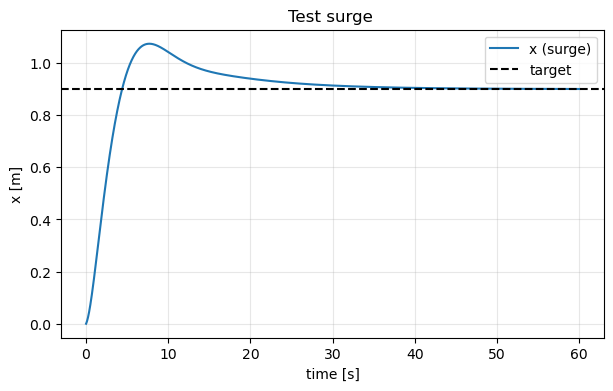

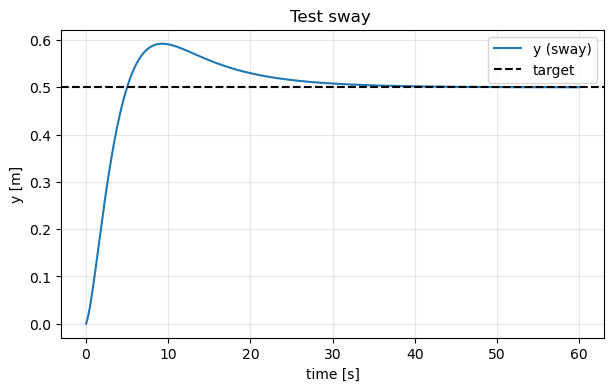

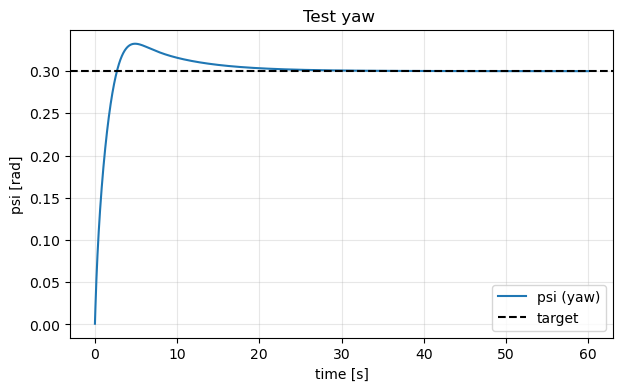

Surge - % time in 70-150cm window: 96.26666666666667
Sway  - % time within 5cm of target: 76.41666666666667
Yaw   - % time within ~3deg of target: 97.08333333333333


In [3]:

#SURGE---------------------------
res_u = run_simulation('pid', x_ref=0.9, y_ref=0.0, psi_ref=0.0,
                        current_magnitude=0.0, gains=gains_pid)
plt.figure(figsize=(7,4))
plt.plot(res_u['t'], res_u['x'], label='x (surge)')
plt.axhline(0.9, color='k', linestyle='--', label='target')
plt.xlabel('time [s]'); plt.ylabel('x [m]'); plt.legend(); plt.grid(alpha=0.3)
plt.title('Test surge ')
plt.show()

#SWAY--------------------------------------------
res_v = run_simulation('pid', x_ref=0.0, y_ref=0.5, psi_ref=0.0,
                        current_magnitude=0.0, gains=gains_pid)
plt.figure(figsize=(7,4))
plt.plot(res_v['t'], res_v['y'], label='y (sway)')
plt.axhline(0.5, color='k', linestyle='--', label='target')
plt.xlabel('time [s]'); plt.ylabel('y [m]'); plt.legend(); plt.grid(alpha=0.3)
plt.title('Test sway ')
plt.show()

#YAW-------------------------------------------------
res_r = run_simulation('pid', x_ref=0.0, y_ref=0.0, psi_ref=0.3,
                        current_magnitude=0.0, gains=gains_pid)
plt.figure(figsize=(7,4))
plt.plot(res_r['t'], res_r['psi'], label='psi (yaw)')
plt.axhline(0.3, color='k', linestyle='--', label='target')
plt.xlabel('time [s]'); plt.ylabel('psi [rad]'); plt.legend(); plt.grid(alpha=0.3)
plt.title('Test yaw ')
plt.show()


# METRICHE -------------------------------------------------------------------
print('Surge - % time in 70-150cm window:', distance_metrics(res_u, net_x=2.0)['pct_in_window'])
print('Sway  - % time within 5cm of target:', offset_metrics(res_v, target=0.5, key='y'))
print('Yaw   - % time within ~3deg of target:', offset_metrics(res_r, target=0.3, key='psi', tolerance=0.05))

In [4]:
print("=== SURGE ===")
print(full_metrics(res_u, target=0.9, key='x'))

print("\n=== SWAY ===")
print(full_metrics(res_v, target=0.5, key='y'))

print("\n=== YAW ===")
print(full_metrics(res_r, target=0.3, key='psi'))

=== SURGE ===
{'settling_time': 18.87, 'overshoot_pct': 19.36018875030083, 'steady_state_error': 0.001009953810964248}

=== SWAY ===
{'settling_time': 21.35, 'overshoot_pct': 18.443905158722895, 'steady_state_error': 0.000322539897057772}

=== YAW ===
{'settling_time': 10.35, 'overshoot_pct': 10.825996082171718, 'steady_state_error': 1.8521047812580793e-05}


## Effect of currents

Surge 0° - % time in 70-150cm window: 90.40833333333333
max|tau_u| (steady): 5.219626602377009
{'settling_time': 29.89, 'overshoot_pct': 62.153104161103414, 'steady_state_error': 2.1860328480727276e-07}
Surge 90° - % time in 70-150cm window: 98.13333333333333
max|tau_u| (steady): 4.4443527055248335
{'settling_time': 18.87, 'overshoot_pct': 19.36018875030083, 'steady_state_error': 1.6822483721590231e-06}
Surge 180° - % time in 70-150cm window: 93.79166666666666
max|tau_u| (steady): 6.030533915998186
{'settling_time': 19.29, 'overshoot_pct': 0.5480792173589988, 'steady_state_error': 3.602344589292983e-08}
Surge 270° - % time in 70-150cm window: 98.13333333333333
max|tau_u| (steady): 4.4443527055248335
{'settling_time': 18.87, 'overshoot_pct': 19.360188750300804, 'steady_state_error': 1.6822483721590231e-06}


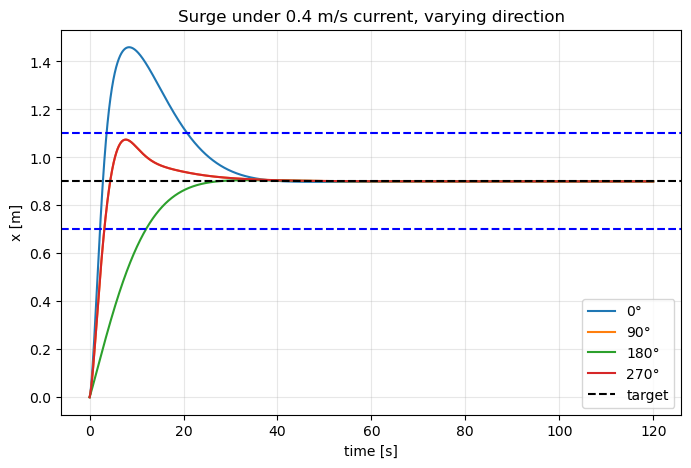

Sway 0° - % time within 10cm of target: 97.0
max|tau_v| (steady): 2.603205811937706
{'settling_time': 21.35, 'overshoot_pct': 18.443905158722895, 'steady_state_error': 1.2381652481074923e-07}
Sway 90° - % time within 10cm of target: 79.525
max|tau_v| (steady): 6.735220630968121
{'settling_time': 31.52, 'overshoot_pct': 100.14627063387547, 'steady_state_error': -2.415542715128449e-06}
Sway 180° - % time within 10cm of target: 97.0
max|tau_v| (steady): 2.603205811937706
{'settling_time': 21.35, 'overshoot_pct': 18.443905158722895, 'steady_state_error': 1.2381652481074923e-07}
Sway 270° - % time within 10cm of target: 83.7
max|tau_v| (steady): 6.753891726732014
{'settling_time': 25.41, 'overshoot_pct': 1.9082442673403532, 'steady_state_error': 1.5464190806779854e-06}


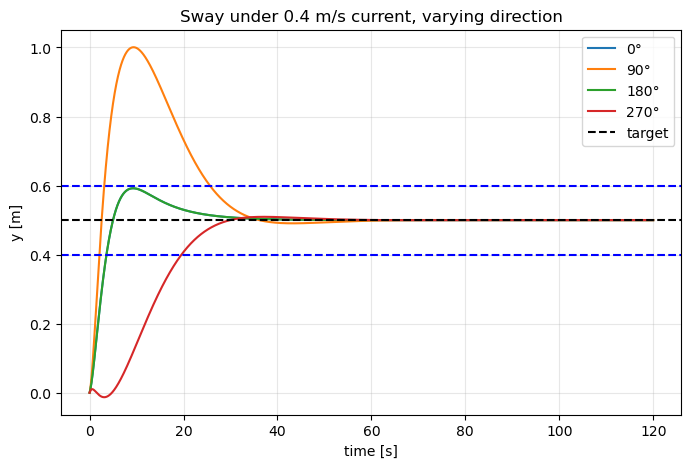

Yaw 0° - % time within ~3deg of target: 98.54166666666667
{'settling_time': 10.35, 'overshoot_pct': 10.825996082171718, 'steady_state_error': 2.023993417310521e-09}
Yaw 90° - % time within ~3deg of target: 98.54166666666667
{'settling_time': 10.35, 'overshoot_pct': 10.825996082171718, 'steady_state_error': 2.023993417310521e-09}
Yaw 180° - % time within ~3deg of target: 98.54166666666667
{'settling_time': 10.35, 'overshoot_pct': 10.825996082171718, 'steady_state_error': 2.023993417310521e-09}
Yaw 270° - % time within ~3deg of target: 98.54166666666667
{'settling_time': 10.35, 'overshoot_pct': 10.825996082171718, 'steady_state_error': 2.023993417310521e-09}


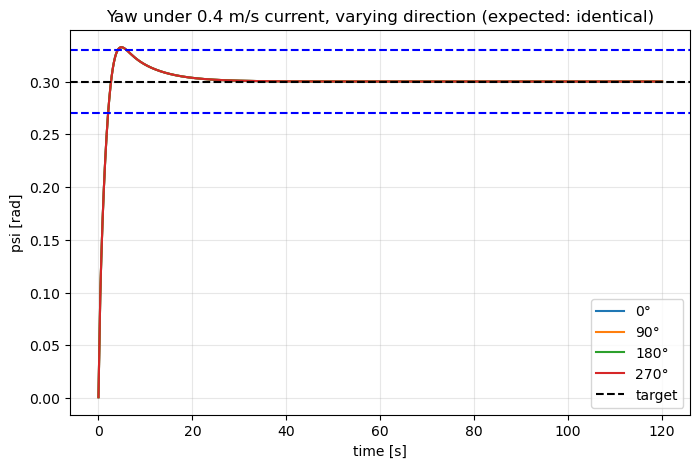

In [5]:
current_mag = 0.4
directions = [0, 90, 180, 270]

# --- SURGE ------------------------------------------------------------------
plt.figure(figsize=(8,5))
for dirn in directions:
    res = run_simulation('pid', x_ref=0.9, y_ref=0.0, psi_ref=0.0,
                          current_magnitude=current_mag, current_direction_deg=dirn,
                          gains=gains_pid, duration=120.0)
    plt.plot(res['t'], res['x'], label=f'{dirn}°')
    mask = res['t'] > 0.5
    print(f'Surge {dirn}° - % time in 70-150cm window:', distance_metrics(res, net_x=2.0)['pct_in_window'])
    print('max|tau_u| (steady):', np.abs(res['tau_u'][mask]).max())
    print(full_metrics(res, target=0.9, key='x'))
plt.axhline(0.9, color='k', linestyle='--', label='target')
plt.axhline(1.1, color='b', linestyle='--' )
plt.axhline(0.7, color='b', linestyle='--' )
plt.xlabel('time [s]'); plt.ylabel('x [m]'); plt.legend(); plt.grid(alpha=0.3)
plt.title('Surge under 0.4 m/s current, varying direction')
plt.show()

# --- SWAY --------------------------------------------------------------------
plt.figure(figsize=(8,5))
for dirn in directions:
    res = run_simulation('pid', x_ref=0.0, y_ref=0.5, psi_ref=0.0,
                          current_magnitude=current_mag, current_direction_deg=dirn,
                          gains=gains_pid, duration=120.0)
    plt.plot(res['t'], res['y'], label=f'{dirn}°')
    mask = res['t'] > 0.5
    print(f'Sway {dirn}° - % time within 10cm of target:', offset_metrics(res, target=0.5, key='y', tolerance=0.10))
    print('max|tau_v| (steady):', np.abs(res['tau_v'][mask]).max())
    print(full_metrics(res, target=0.5, key='y'))
plt.axhline(0.5, color='k', linestyle='--', label='target')
plt.axhline(0.6, color='b', linestyle='--' )
plt.axhline(0.4, color='b', linestyle='--' )
plt.xlabel('time [s]'); plt.ylabel('y [m]'); plt.legend(); plt.grid(alpha=0.3)
plt.title('Sway under 0.4 m/s current, varying direction')
plt.show()

# --- YAW -----------------------------------------------------------------------
plt.figure(figsize=(8,5))
for dirn in directions:
    res = run_simulation('pid', x_ref=0.0, y_ref=0.0, psi_ref=0.3,
                          current_magnitude=current_mag, current_direction_deg=dirn,
                          gains=gains_pid, duration=120.0)
    plt.plot(res['t'], res['psi'], label=f'{dirn}°')
    print(f'Yaw {dirn}° - % time within ~3deg of target:', offset_metrics(res, target=0.3, key='psi', tolerance=0.05))
    print(full_metrics(res, target=0.3, key='psi'))
plt.axhline(0.3, color='k', linestyle='--', label='target')
plt.axhline(0.33, color='b', linestyle='--' )
plt.axhline(0.27, color='b', linestyle='--' )
plt.xlabel('time [s]'); plt.ylabel('psi [rad]'); plt.legend(); plt.grid(alpha=0.3)
plt.title('Yaw under 0.4 m/s current, varying direction (expected: identical)')
plt.show()

## Note — current has no effect on yaw

By design (Assumption 3 in the paper — decoupled DOFs, diagonal M/D matrices), the yaw dynamics ($\dot r$) depend only on $r$ and $\tau_r$; no term in `dynamics()` couples surge/sway current disturbance into yaw. This means changing `current_direction_deg` produces identical yaw responses regardless of angle — this is expected model behavior, not a bug. A current-induced yaw moment (e.g. from an off-center pressure effect) would require extending the model and revisiting Assumption 3, which is out of scope here.

## Note — initial error magnitude affects settling time

The mismatch between the theoretical $t_s$ and the observed settling
time depends on how large the initial error is, not on the starting
position itself. A large initial error triggers a strong control
force, which drives velocity up — and it's exactly at higher
velocities that the quadratic damping term dominates over the linear
one, pulling the response away from the linearized design. A smaller
initial error (e.g. starting already close to the target) would stay
closer to the small-velocity regime where the linear approximation
holds, and settling time should be closer to the theoretical $t_s$.
This matters for interpreting results: the "start from zero" tests
used here represent a worst-case transient, not necessarily the
error magnitude expected in the real deployment scenario.

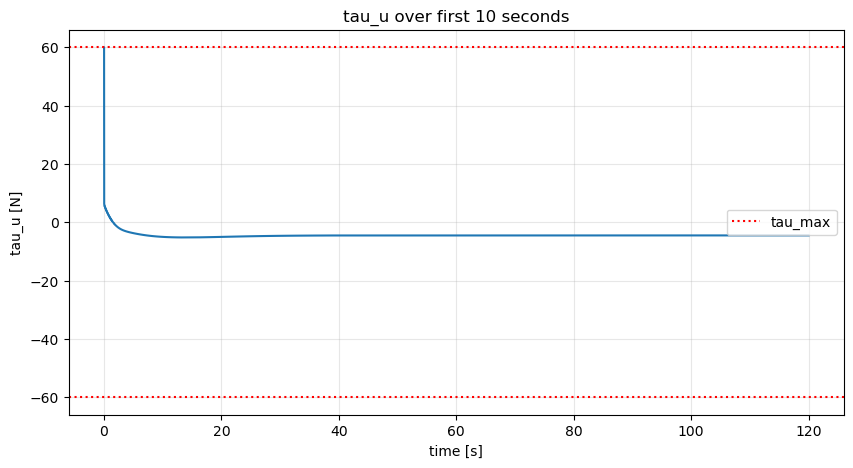

In [ ]:
res_check = run_simulation('pid', x_ref=0.9, y_ref=0.0, psi_ref=0.0,
                            current_magnitude=0.4, gains=gains_pid, duration=120.0)

plt.figure(figsize=(10,5))
plt.plot(res_check['t'], res_check['tau_u'])
plt.axhline(60, color='r', linestyle=':', label='tau_max')
plt.axhline(-60, color='r', linestyle=':')
plt.xlabel('time [s]'); plt.ylabel('tau_u [N]'); plt.legend(); plt.grid(alpha=0.3)
plt.title('tau_u')
plt.show()

# SMC tuning

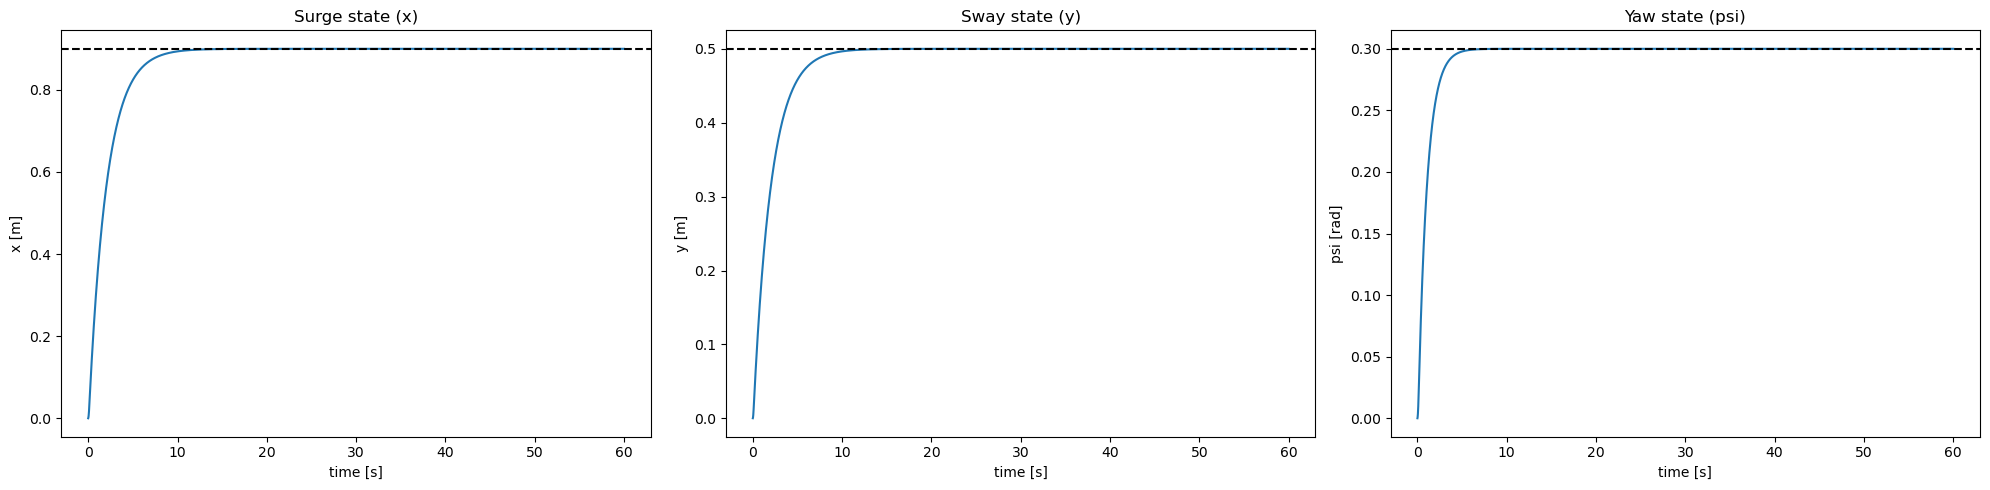

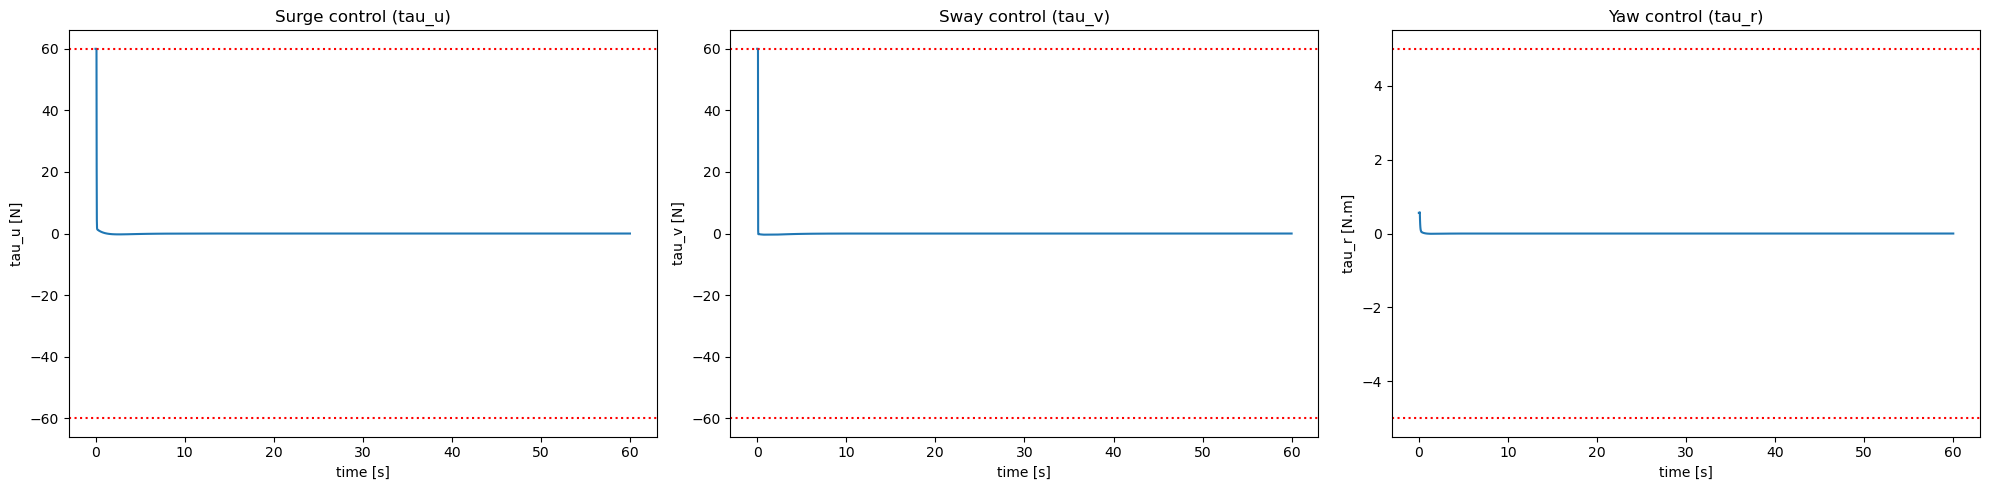

=== SURGE ===
% time in window: 97.2
{'settling_time': 6.05, 'overshoot_pct': 0.0, 'steady_state_error': -2.5702773243097e-12}
Chattering rate: 0.0 switch/s

=== SWAY ===
% time within 10cm: 94.56666666666666
{'settling_time': 6.04, 'overshoot_pct': 0.0, 'steady_state_error': -1.4174217355389374e-12}
Chattering rate: 0.0 switch/s

=== YAW ===
% time within ~3deg: 96.88333333333333
{'settling_time': 3.0700000000000003, 'overshoot_pct': 0.0, 'steady_state_error': -2.7200464103316335e-15}
Chattering rate: 0.0 switch/s


In [23]:
gains_smc = dict(
    lambda_u=0.5, k_u=3.55, phi_u=0.083,
    lambda_v=0.5, k_v=4.7,  phi_v=0.09,
    lambda_r=1.0, k_r=2.0,  phi_r=0.1,
    tau_max_linear=60.0,
)

# --- Run, zero current, tutti e tre gli assi isolati -------------------------
res_u0 = run_simulation('smc', x_ref=0.9, y_ref=0.0, psi_ref=0.0,
                         current_magnitude=0.0, gains=gains_smc, duration=60.0)
res_v0 = run_simulation('smc', x_ref=0.0, y_ref=0.5, psi_ref=0.0,
                         current_magnitude=0.0, gains=gains_smc, duration=60.0)
res_r0 = run_simulation('smc', x_ref=0.0, y_ref=0.0, psi_ref=0.3,
                         current_magnitude=0.0, gains=gains_smc, duration=60.0)

# --- Grafici di STATO (x, y, psi) --------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
axes[0].plot(res_u0['t'], res_u0['x']); axes[0].axhline(0.9, color='k', linestyle='--')
axes[0].set_title('Surge state (x)'); axes[0].set_xlabel('time [s]'); axes[0].set_ylabel('x [m]')
axes[1].plot(res_v0['t'], res_v0['y']); axes[1].axhline(0.5, color='k', linestyle='--')
axes[1].set_title('Sway state (y)'); axes[1].set_xlabel('time [s]'); axes[1].set_ylabel('y [m]')
axes[2].plot(res_r0['t'], res_r0['psi']); axes[2].axhline(0.3, color='k', linestyle='--')
axes[2].set_title('Yaw state (psi)'); axes[2].set_xlabel('time [s]'); axes[2].set_ylabel('psi [rad]')
plt.tight_layout(); plt.show()

# --- Grafici di CONTROLLO (tau) -- per vedere il chattering a occhio --------
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
axes[0].plot(res_u0['t'], res_u0['tau_u'])
axes[0].axhline(60, color='r', linestyle=':'); axes[0].axhline(-60, color='r', linestyle=':')
axes[0].set_title('Surge control (tau_u)'); axes[0].set_xlabel('time [s]'); axes[0].set_ylabel('tau_u [N]')
axes[1].plot(res_v0['t'], res_v0['tau_v'])
axes[1].axhline(60, color='r', linestyle=':'); axes[1].axhline(-60, color='r', linestyle=':')
axes[1].set_title('Sway control (tau_v)'); axes[1].set_xlabel('time [s]'); axes[1].set_ylabel('tau_v [N]')
axes[2].plot(res_r0['t'], res_r0['tau_r'])
axes[2].axhline(5, color='r', linestyle=':'); axes[2].axhline(-5, color='r', linestyle=':')
axes[2].set_title('Yaw control (tau_r)'); axes[2].set_xlabel('time [s]'); axes[2].set_ylabel('tau_r [N.m]')
plt.tight_layout(); plt.show()

# --- Metriche numeriche -------------------------------------------------------
print('=== SURGE ===')
print('% time in window:', distance_metrics(res_u0, net_x=2.0)['pct_in_window'])
print(full_metrics(res_u0, target=0.9, key='x'))
print('Chattering rate:', chattering_metric(res_u0), 'switch/s')

print('\n=== SWAY ===')
print('% time within 10cm:', offset_metrics(res_v0, target=0.5, key='y', tolerance=0.10))
print(full_metrics(res_v0, target=0.5, key='y'))
print('Chattering rate:', chattering_metric(res_v0), 'switch/s')

print('\n=== YAW ===')
print('% time within ~3deg:', offset_metrics(res_r0, target=0.3, key='psi', tolerance=0.05))
print(full_metrics(res_r0, target=0.3, key='psi'))
print('Chattering rate:', chattering_metric(res_r0), 'switch/s')

SMC Surge 0° - % time in window: 97.25  max|tau_u| (steady): 4.520799999999214  chattering: 0.0
{'settling_time': 5.66, 'overshoot_pct': 1.3816676792609561, 'steady_state_error': 0.0124350091092581}
SMC Surge 90° - % time in window: 97.2  max|tau_u| (steady): 0.7480248192711879  chattering: 0.0
{'settling_time': 6.05, 'overshoot_pct': 0.0, 'steady_state_error': -2.5702773243097e-12}
SMC Surge 180° - % time in window: 97.06666666666666  max|tau_u| (steady): 10.346797054053035  chattering: 0.0
{'settling_time': 6.8100000000000005, 'overshoot_pct': 0.0, 'steady_state_error': -0.012435009117745865}
SMC Surge 270° - % time in window: 97.2  max|tau_u| (steady): 0.7480248192711879  chattering: 0.0
{'settling_time': 6.05, 'overshoot_pct': 0.0, 'steady_state_error': -2.5702773243097e-12}


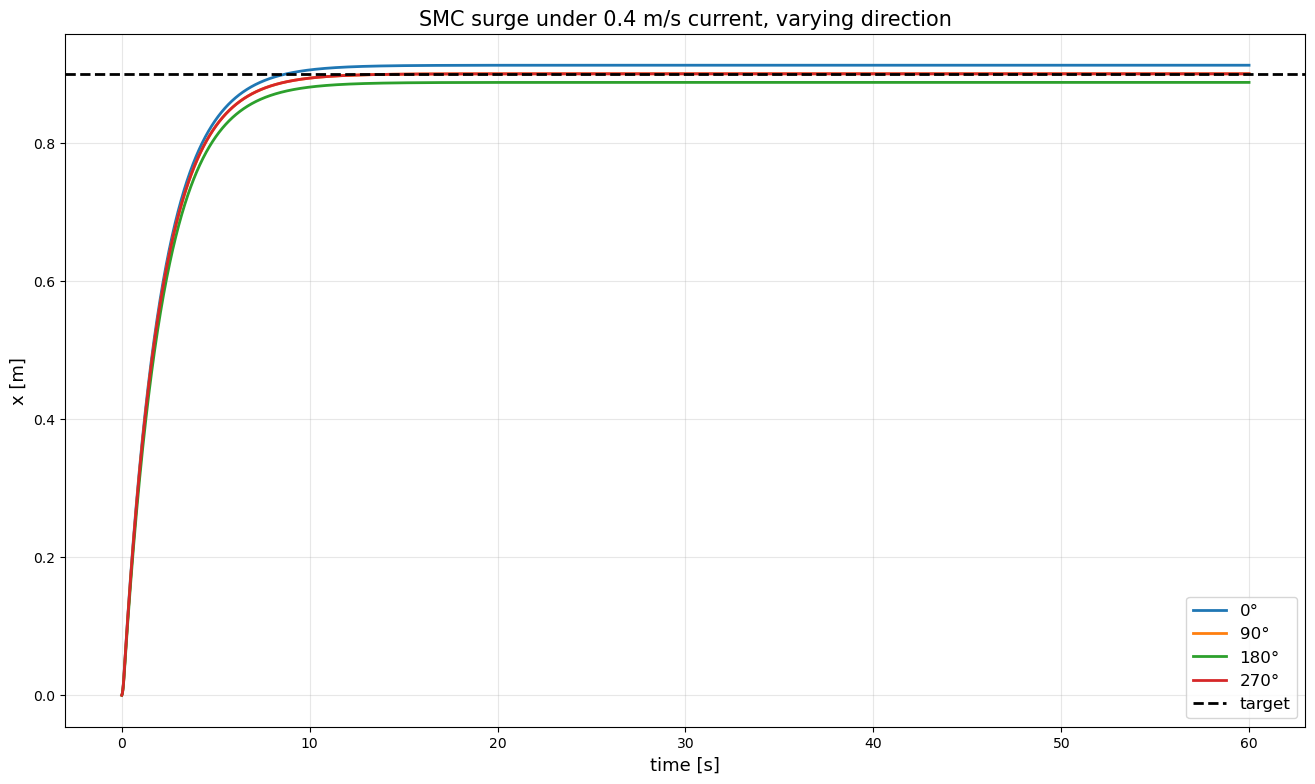

SMC Sway 0° - % time within 10cm: 94.56666666666666  max|tau_v| (steady): 0.7686429389379728  chattering: 0.0
{'settling_time': 6.04, 'overshoot_pct': 0.0, 'steady_state_error': -1.4170331574803186e-12}
SMC Sway 90° - % time within 10cm: 94.66666666666667  max|tau_v| (steady): 13.607944811572889  chattering: 0.0
{'settling_time': 5.72, 'overshoot_pct': 1.0179994300250073, 'steady_state_error': 0.0050899971484634765}
SMC Sway 180° - % time within 10cm: 94.56666666666666  max|tau_v| (steady): 0.7686429389379728  chattering: 0.0
{'settling_time': 6.04, 'overshoot_pct': 0.0, 'steady_state_error': -1.4170331574803186e-12}
SMC Sway 270° - % time within 10cm: 94.36666666666666  max|tau_v| (steady): 16.656163304815337  chattering: 0.0
{'settling_time': 6.53, 'overshoot_pct': 0.0, 'steady_state_error': -0.0050899971518880704}


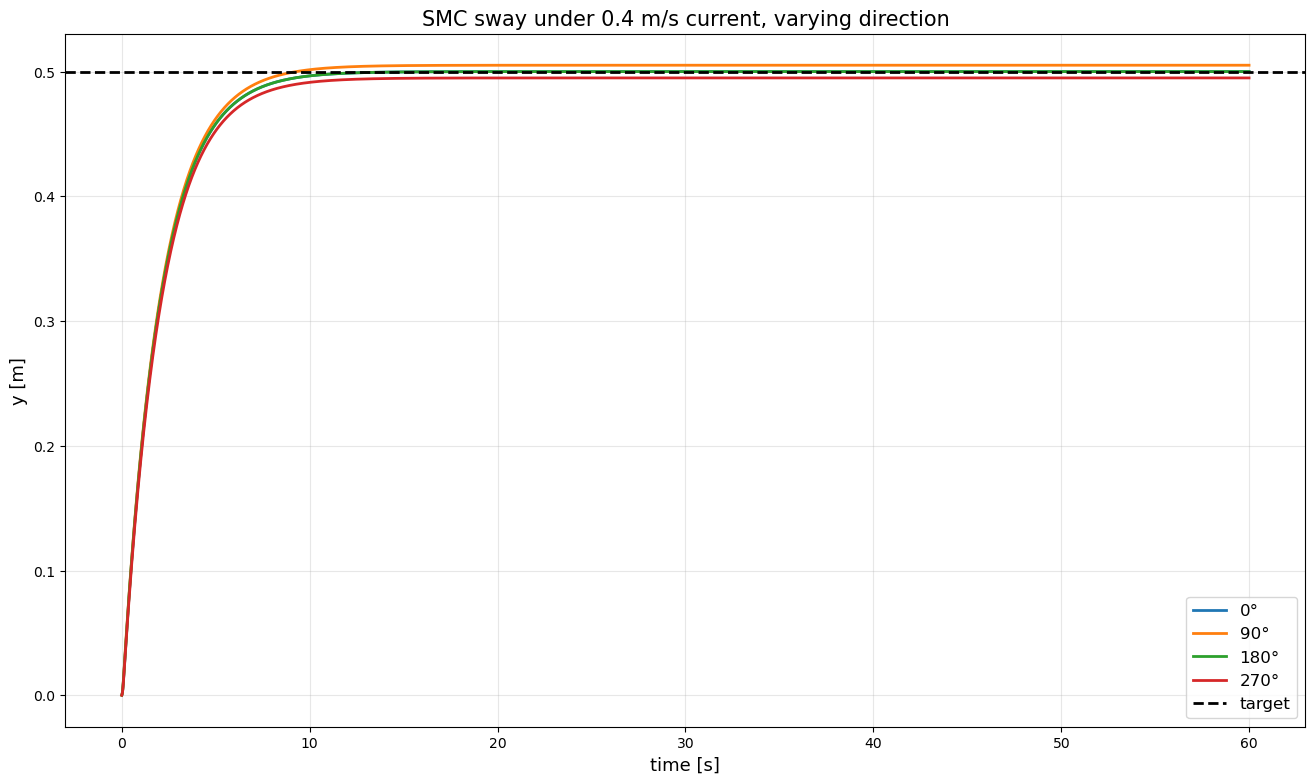

In [21]:
current_mag = 0.4
directions = [0, 90, 180, 270]

# --- SMC SURGE ------------------------------------------------------------------
plt.figure(figsize=(16, 9))
for dirn in directions:
    res = run_simulation('smc', x_ref=0.9, y_ref=0.0, psi_ref=0.0,
                          current_magnitude=current_mag, current_direction_deg=dirn,
                          gains=gains_smc, duration=60.0)
    plt.plot(res['t'], res['x'], label=f'{dirn}°', linewidth=2)
    mask = res['t'] > 0.5
    print(f'SMC Surge {dirn}° - % time in window:', distance_metrics(res, net_x=2.0)['pct_in_window'],
          ' max|tau_u| (steady):', np.abs(res['tau_u'][mask]).max(),
          ' chattering:', chattering_metric(res))
    print(full_metrics(res, target=0.9, key='x'))
plt.axhline(0.9, color='k', linestyle='--', label='target', linewidth=2)
plt.xlabel('time [s]', fontsize=13); plt.ylabel('x [m]', fontsize=13)
plt.legend(fontsize=12); plt.grid(alpha=0.3)
plt.title('SMC surge under 0.4 m/s current, varying direction', fontsize=15)
plt.show()

# --- SMC SWAY --------------------------------------------------------------------
plt.figure(figsize=(16, 9))
for dirn in directions:
    res = run_simulation('smc', x_ref=0.0, y_ref=0.5, psi_ref=0.0,
                          current_magnitude=current_mag, current_direction_deg=dirn,
                          gains=gains_smc, duration=60.0)
    plt.plot(res['t'], res['y'], label=f'{dirn}°', linewidth=2)
    mask = res['t'] > 0.5
    print(f'SMC Sway {dirn}° - % time within 10cm:', offset_metrics(res, target=0.5, key='y', tolerance=0.10),
          ' max|tau_v| (steady):', np.abs(res['tau_v'][mask]).max(),
          ' chattering:', chattering_metric(res))
    print(full_metrics(res, target=0.5, key='y'))
plt.axhline(0.5, color='k', linestyle='--', label='target', linewidth=2)
plt.xlabel('time [s]', fontsize=13); plt.ylabel('y [m]', fontsize=13)
plt.legend(fontsize=12); plt.grid(alpha=0.3)
plt.title('SMC sway under 0.4 m/s current, varying direction', fontsize=15)
plt.show()

## SMC steady-state offset under current

Even though $\tau_{eq}$ compensates the nominal damping model, a small
residual offset appears under current — because $\tau_{eq}$ uses the
measured (absolute) velocity $u$, not the true relative velocity $u_r$
(unmeasured, since the controller doesn't know the current). This
mismatch should be corrected by the switching term, but inside the
boundary layer ($|s| < \phi$), `sat(s/phi)` acts as a proportional
gain rather than a full ±1 correction — too weak to fully close the
gap. Reducing $\phi$ and/or increasing $k$ reduces the offset, at the
cost of reintroducing chattering if pushed too far — same
precision-vs-chattering trade-off as always with the boundary layer.